In [52]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

from baseline_cnn import BaselineCNN
from utils import train, get_loaders, plot_training_history, plot_sample_predictions, \
set_seed, plot_confusion_matrix, plot_cumulative_training_history, evaluate_model

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [2]:
# personal
DATA_DIR = Path("../data")

#colab
#add cinic_data folder to personal google drive and drop the data downloaded from kaggle
'''
from google.colab import drive
drive.mount('/content/drive')

#DATA_DIR = Path("/content/drive/MyDrive/cinic_data")
DATA_DIR = Path("/content/drive/MyDrive/cinic_subset")

if not os.path.exists('/content/cinic_subset'):
    print("Copying data from drive...", flush=True)
    shutil.copytree(DATA_DIR, '/content/cinic_subset')
    print("Done!", flush=True)
else:
    print("Data already exists locally!", flush=True)


DATA_DIR = Path("/content/cinic_subset")
'''

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"


In [4]:
BATCH_SIZE = 256
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

## Baseline CNN

In [5]:
checkpoint_dir = 'baseline_models'
os.makedirs(checkpoint_dir, exist_ok=True)

Starting with small BaselineCNN: 

Conv layers: [32], Kernel sizes: [3], FC layers: [10]

In [6]:
model0 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32], kernel_sizes = [3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0.parameters(), lr=1e-3)

In [7]:
set_seed(42)
model0_history = train(model0, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model0')

Epoch 1/10 | Train Loss: 2.1411 | Valid Loss: 2.0211 | Valid Acc: 0.2390
Epoch 2/10 | Train Loss: 1.9394 | Valid Loss: 1.8698 | Valid Acc: 0.2912
Epoch 3/10 | Train Loss: 1.8362 | Valid Loss: 1.8109 | Valid Acc: 0.3230
Epoch 4/10 | Train Loss: 1.7896 | Valid Loss: 1.7727 | Valid Acc: 0.3326
Epoch 5/10 | Train Loss: 1.7659 | Valid Loss: 1.7651 | Valid Acc: 0.3333
Epoch 6/10 | Train Loss: 1.7482 | Valid Loss: 1.7355 | Valid Acc: 0.3495
Epoch 7/10 | Train Loss: 1.7331 | Valid Loss: 1.7276 | Valid Acc: 0.3519
Epoch 8/10 | Train Loss: 1.7210 | Valid Loss: 1.7155 | Valid Acc: 0.3583
Epoch 9/10 | Train Loss: 1.7077 | Valid Loss: 1.7133 | Valid Acc: 0.3569
Epoch 10/10 | Train Loss: 1.6981 | Valid Loss: 1.7056 | Valid Acc: 0.3560
Best validation accuracy: 0.3583


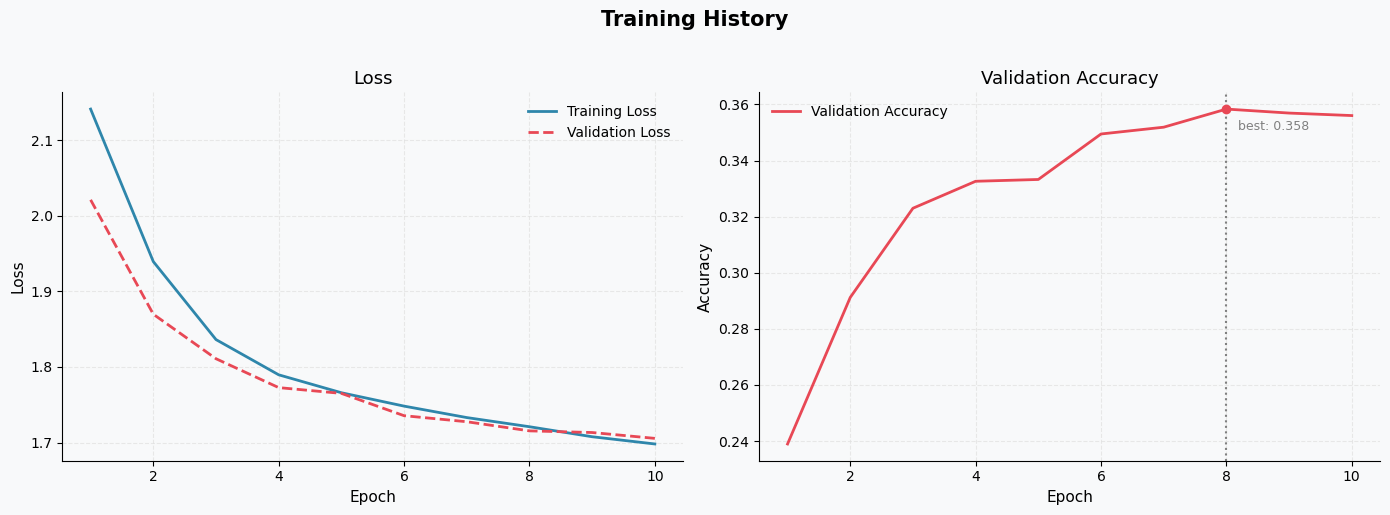

In [8]:
plot_training_history(model0_history)

adding another, larger convolutional layer


Conv layers: [32, 64], Kernel sizes: [3, 3], FC layers: [10]

In [11]:
model1 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32, 64], kernel_sizes = [3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=1e-3)

In [12]:
set_seed(42)
model1_history = train(model1, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model1')

Epoch 1/10 | Train Loss: 1.8886 | Valid Loss: 1.7351 | Valid Acc: 0.3483
Epoch 2/10 | Train Loss: 1.6467 | Valid Loss: 1.6146 | Valid Acc: 0.3923
Epoch 3/10 | Train Loss: 1.5610 | Valid Loss: 1.5842 | Valid Acc: 0.4042
Epoch 4/10 | Train Loss: 1.5168 | Valid Loss: 1.5009 | Valid Acc: 0.4360
Epoch 5/10 | Train Loss: 1.4818 | Valid Loss: 1.5881 | Valid Acc: 0.4019
Epoch 6/10 | Train Loss: 1.4549 | Valid Loss: 1.4599 | Valid Acc: 0.4478
Epoch 7/10 | Train Loss: 1.4291 | Valid Loss: 1.4896 | Valid Acc: 0.4433
Epoch 8/10 | Train Loss: 1.4071 | Valid Loss: 1.4358 | Valid Acc: 0.4600
Epoch 9/10 | Train Loss: 1.3867 | Valid Loss: 1.5931 | Valid Acc: 0.4288
Epoch 10/10 | Train Loss: 1.3699 | Valid Loss: 1.4065 | Valid Acc: 0.4775
Best validation accuracy: 0.4775


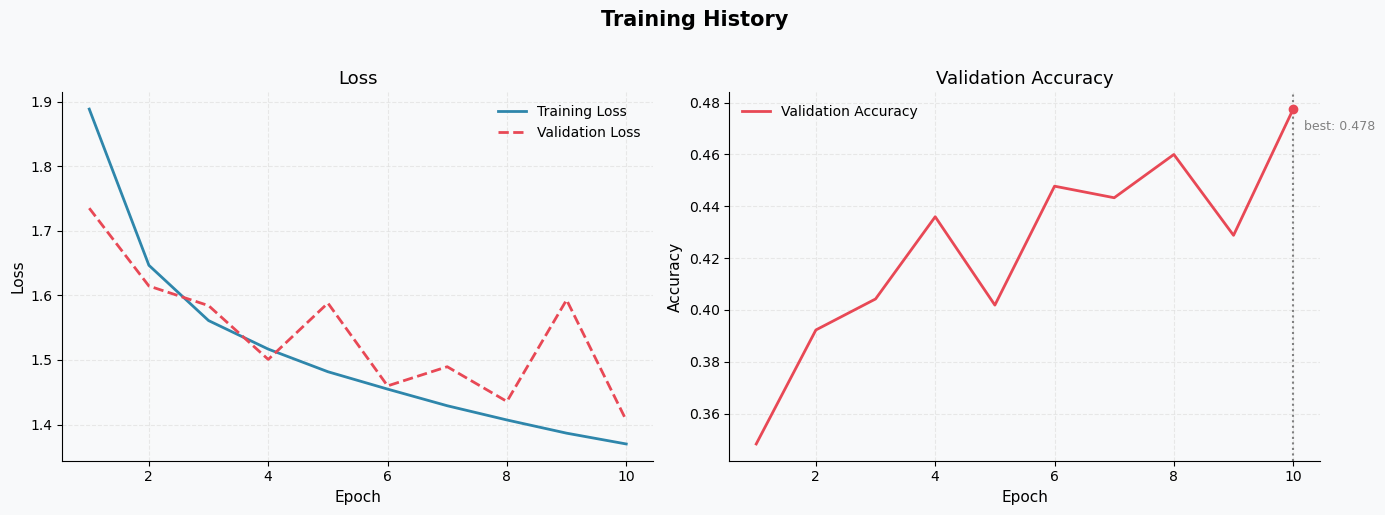

In [13]:
plot_training_history(model1_history)

adding another convolutional layer

In [14]:
model2 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32, 64, 128], kernel_sizes = [3, 3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

In [15]:
set_seed(42)
model2_history = train(model2, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model2')

Epoch 1/10 | Train Loss: 1.6622 | Valid Loss: 1.4484 | Valid Acc: 0.4454
Epoch 2/10 | Train Loss: 1.3606 | Valid Loss: 1.5175 | Valid Acc: 0.4501
Epoch 3/10 | Train Loss: 1.2567 | Valid Loss: 1.3133 | Valid Acc: 0.5183
Epoch 4/10 | Train Loss: 1.1902 | Valid Loss: 1.2144 | Valid Acc: 0.5491
Epoch 5/10 | Train Loss: 1.1398 | Valid Loss: 1.6174 | Valid Acc: 0.4377
Epoch 6/10 | Train Loss: 1.1029 | Valid Loss: 1.2097 | Valid Acc: 0.5637
Epoch 7/10 | Train Loss: 1.0655 | Valid Loss: 1.2659 | Valid Acc: 0.5410
Epoch 8/10 | Train Loss: 1.0356 | Valid Loss: 1.1566 | Valid Acc: 0.5756
Epoch 9/10 | Train Loss: 1.0056 | Valid Loss: 1.1259 | Valid Acc: 0.5921
Epoch 10/10 | Train Loss: 0.9796 | Valid Loss: 1.1269 | Valid Acc: 0.5959
Best validation accuracy: 0.5959


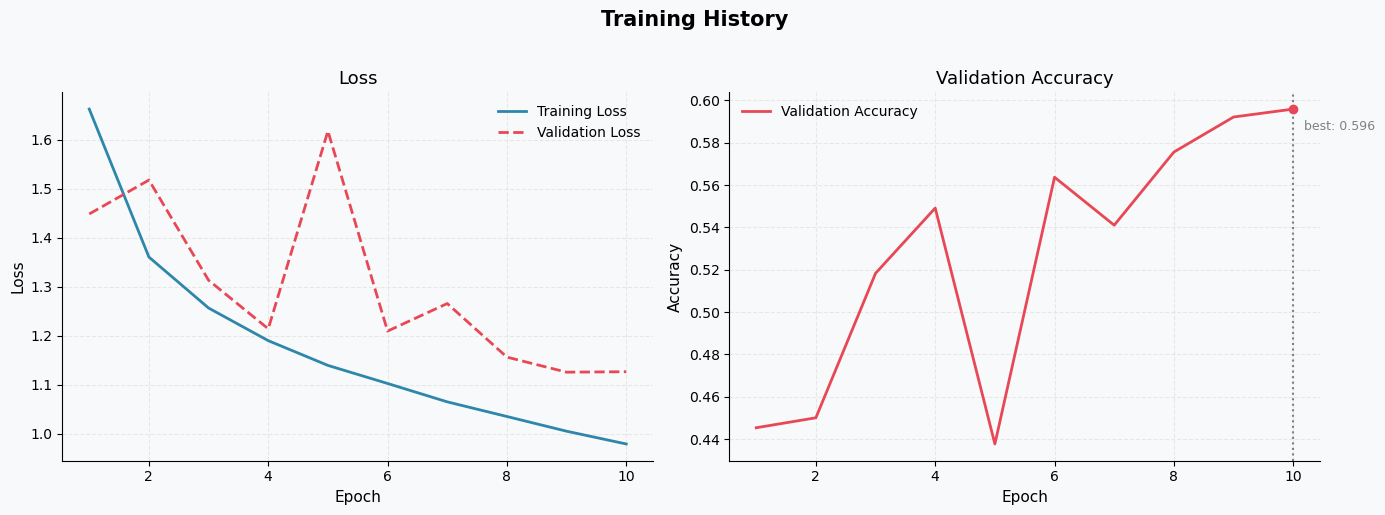

In [16]:
plot_training_history(model2_history)

changing to larger convolutional layers

In [19]:
model3 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)

In [20]:
set_seed(42)
model3_history = train(model3, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model3')

Epoch 1/10 | Train Loss: 1.6081 | Valid Loss: 1.4347 | Valid Acc: 0.4691
Epoch 2/10 | Train Loss: 1.3079 | Valid Loss: 1.4615 | Valid Acc: 0.4676
Epoch 3/10 | Train Loss: 1.1957 | Valid Loss: 1.3992 | Valid Acc: 0.4939
Epoch 4/10 | Train Loss: 1.1184 | Valid Loss: 1.2340 | Valid Acc: 0.5544
Epoch 5/10 | Train Loss: 1.0620 | Valid Loss: 1.4398 | Valid Acc: 0.5002
Epoch 6/10 | Train Loss: 1.0143 | Valid Loss: 1.2224 | Valid Acc: 0.5643
Epoch 7/10 | Train Loss: 0.9637 | Valid Loss: 1.1824 | Valid Acc: 0.5829
Epoch 8/10 | Train Loss: 0.9263 | Valid Loss: 1.1482 | Valid Acc: 0.5945
Epoch 9/10 | Train Loss: 0.8859 | Valid Loss: 1.0403 | Valid Acc: 0.6291
Epoch 10/10 | Train Loss: 0.8470 | Valid Loss: 1.1871 | Valid Acc: 0.5836
Best validation accuracy: 0.6291


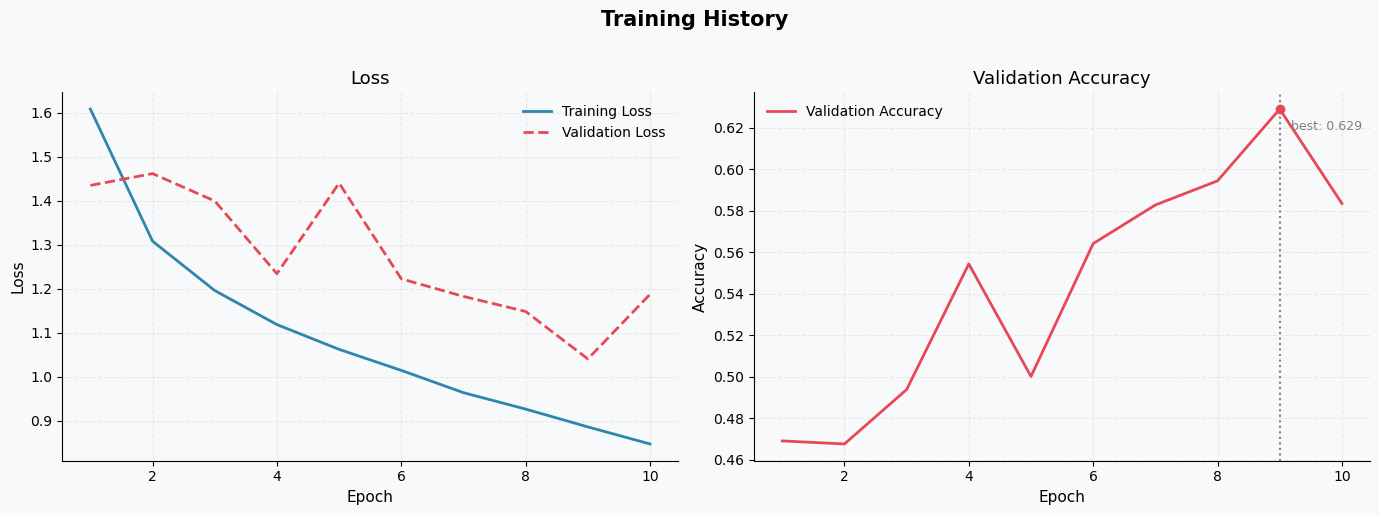

In [21]:
plot_training_history(model3_history)

changing the number of neurons in fully connected layer

In [22]:
model4 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=1e-3)

In [23]:
set_seed(42)
model4_history = train(model4, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model4')

Epoch 1/10 | Train Loss: 1.4957 | Valid Loss: 1.4344 | Valid Acc: 0.4630
Epoch 2/10 | Train Loss: 1.2423 | Valid Loss: 1.3612 | Valid Acc: 0.5207
Epoch 3/10 | Train Loss: 1.1288 | Valid Loss: 1.4254 | Valid Acc: 0.5038
Epoch 4/10 | Train Loss: 1.0497 | Valid Loss: 1.0834 | Valid Acc: 0.6070
Epoch 5/10 | Train Loss: 0.9849 | Valid Loss: 1.2032 | Valid Acc: 0.5714
Epoch 6/10 | Train Loss: 0.9321 | Valid Loss: 1.1269 | Valid Acc: 0.5923
Epoch 7/10 | Train Loss: 0.8828 | Valid Loss: 1.0474 | Valid Acc: 0.6190
Epoch 8/10 | Train Loss: 0.8396 | Valid Loss: 1.0560 | Valid Acc: 0.6328
Epoch 9/10 | Train Loss: 0.7923 | Valid Loss: 1.0730 | Valid Acc: 0.6217
Epoch 10/10 | Train Loss: 0.7502 | Valid Loss: 1.2166 | Valid Acc: 0.5870
Best validation accuracy: 0.6328


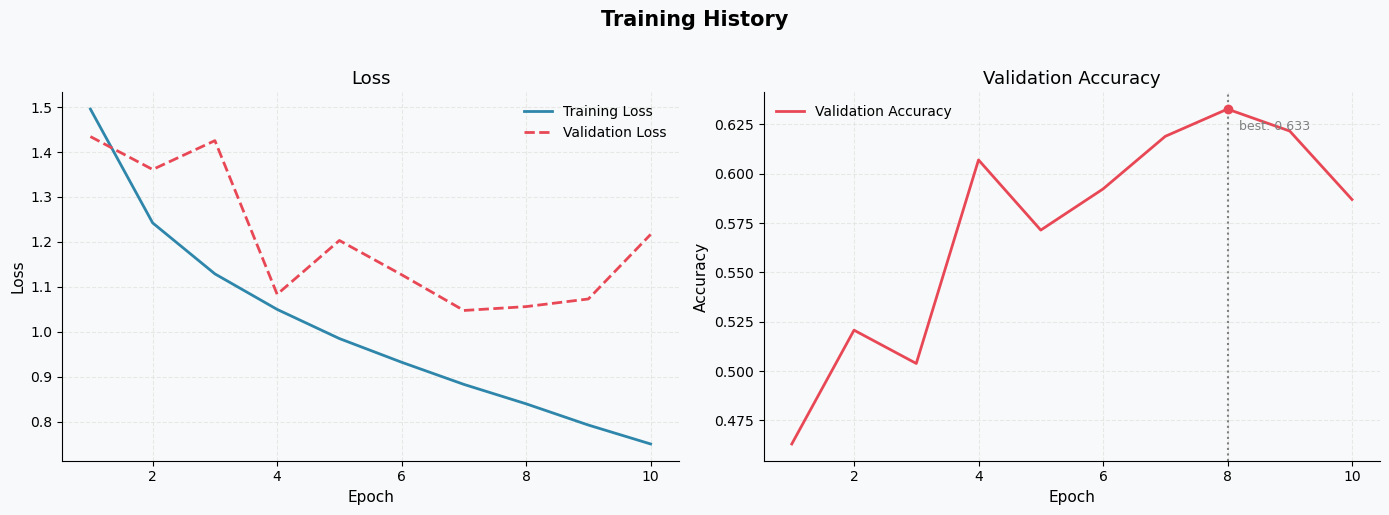

In [24]:
plot_training_history(model4_history)

adding another fully connected layer

In [25]:
model5 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=1e-3)

In [26]:
set_seed(42)
model5_history = train(model5, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model5')

Epoch 1/10 | Train Loss: 1.5188 | Valid Loss: 1.3824 | Valid Acc: 0.4772
Epoch 2/10 | Train Loss: 1.2482 | Valid Loss: 1.2853 | Valid Acc: 0.5241
Epoch 3/10 | Train Loss: 1.1349 | Valid Loss: 1.2569 | Valid Acc: 0.5418
Epoch 4/10 | Train Loss: 1.0577 | Valid Loss: 1.0948 | Valid Acc: 0.6011
Epoch 5/10 | Train Loss: 0.9931 | Valid Loss: 1.2826 | Valid Acc: 0.5470
Epoch 6/10 | Train Loss: 0.9318 | Valid Loss: 1.2947 | Valid Acc: 0.5444
Epoch 7/10 | Train Loss: 0.8827 | Valid Loss: 1.0300 | Valid Acc: 0.6331
Epoch 8/10 | Train Loss: 0.8423 | Valid Loss: 0.9491 | Valid Acc: 0.6629
Epoch 9/10 | Train Loss: 0.7908 | Valid Loss: 1.0681 | Valid Acc: 0.6303
Epoch 10/10 | Train Loss: 0.7451 | Valid Loss: 1.2067 | Valid Acc: 0.5941
Best validation accuracy: 0.6629


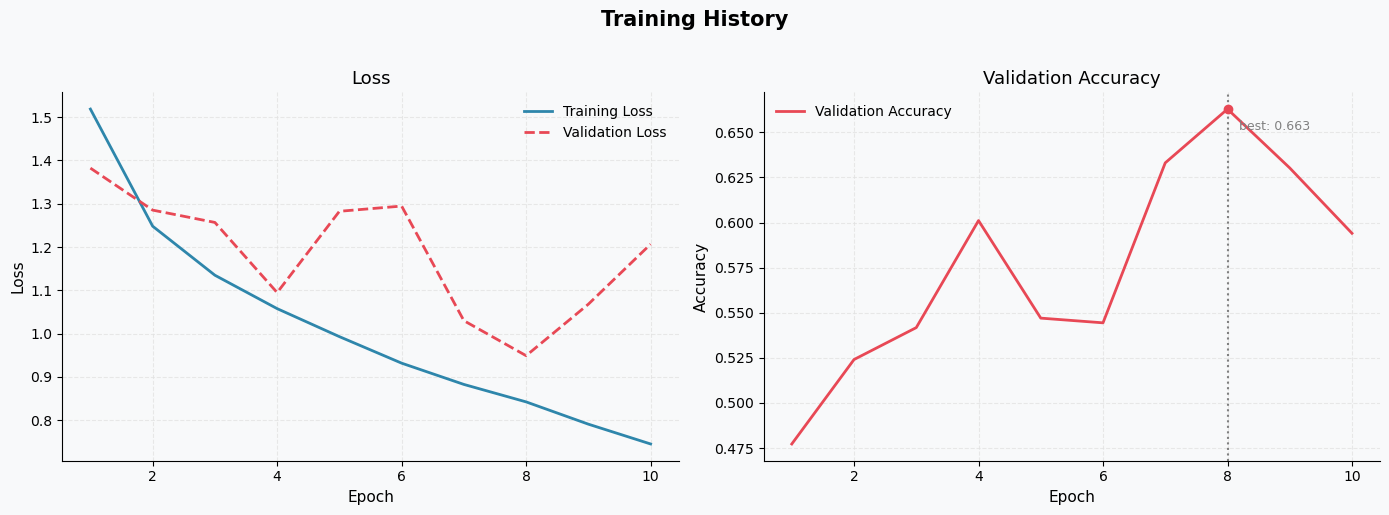

In [27]:
plot_training_history(model5_history)

In [28]:
model6 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256, 512], kernel_sizes = [3, 3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model6.parameters(), lr=1e-3)

In [29]:
set_seed(42)
model6_history = train(model6, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model6')

Epoch 1/10 | Train Loss: 1.3762 | Valid Loss: 1.2849 | Valid Acc: 0.5297
Epoch 2/10 | Train Loss: 1.0582 | Valid Loss: 1.0349 | Valid Acc: 0.6267
Epoch 3/10 | Train Loss: 0.9207 | Valid Loss: 1.2613 | Valid Acc: 0.5846
Epoch 4/10 | Train Loss: 0.8168 | Valid Loss: 0.9952 | Valid Acc: 0.6442
Epoch 5/10 | Train Loss: 0.7231 | Valid Loss: 1.1159 | Valid Acc: 0.6202
Epoch 6/10 | Train Loss: 0.6371 | Valid Loss: 1.1842 | Valid Acc: 0.6241
Epoch 7/10 | Train Loss: 0.5496 | Valid Loss: 0.9022 | Valid Acc: 0.6937
Epoch 8/10 | Train Loss: 0.4688 | Valid Loss: 1.0641 | Valid Acc: 0.6688
Epoch 9/10 | Train Loss: 0.3802 | Valid Loss: 1.3068 | Valid Acc: 0.6429
Epoch 10/10 | Train Loss: 0.3029 | Valid Loss: 1.3552 | Valid Acc: 0.6482
Best validation accuracy: 0.6937


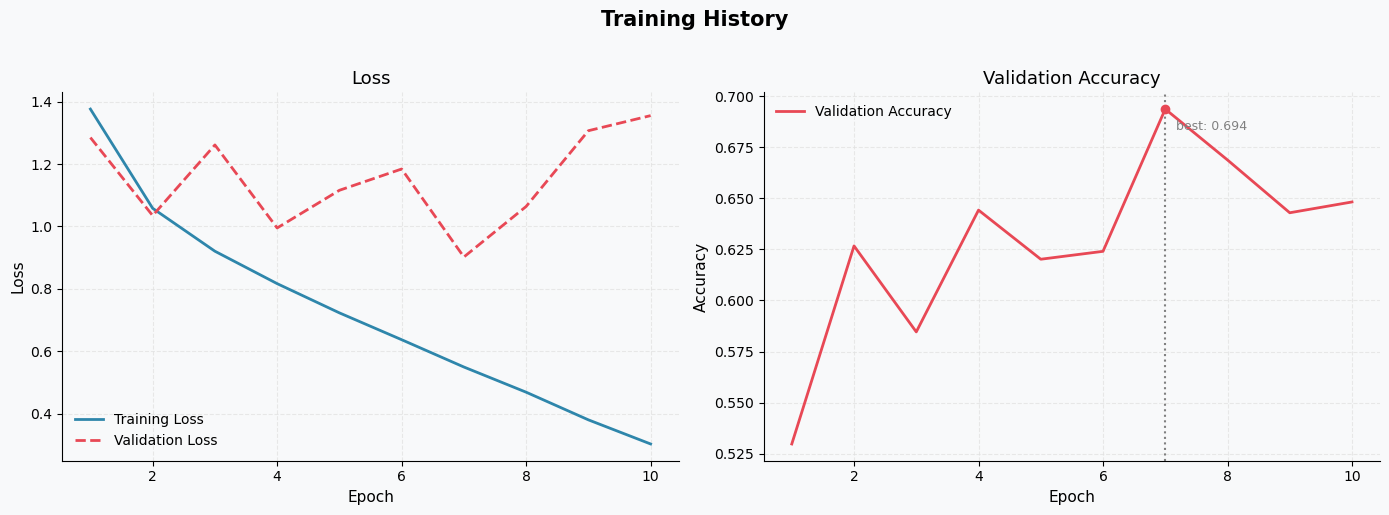

In [30]:
plot_training_history(model6_history)

In [31]:
model7 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256, 512], kernel_sizes = [3, 3, 3, 3],
                    fc_layers = [128, 64, 32], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model7.parameters(), lr=1e-3)

In [32]:
set_seed(42)
model7_history = train(model7, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model7')

Epoch 1/10 | Train Loss: 1.4269 | Valid Loss: 1.2859 | Valid Acc: 0.5226
Epoch 2/10 | Train Loss: 1.0874 | Valid Loss: 1.0625 | Valid Acc: 0.6134
Epoch 3/10 | Train Loss: 0.9439 | Valid Loss: 1.1124 | Valid Acc: 0.6107
Epoch 4/10 | Train Loss: 0.8407 | Valid Loss: 1.0190 | Valid Acc: 0.6362
Epoch 5/10 | Train Loss: 0.7491 | Valid Loss: 1.0992 | Valid Acc: 0.6153
Epoch 6/10 | Train Loss: 0.6622 | Valid Loss: 0.9989 | Valid Acc: 0.6613
Epoch 7/10 | Train Loss: 0.5814 | Valid Loss: 0.9200 | Valid Acc: 0.6883
Epoch 8/10 | Train Loss: 0.5063 | Valid Loss: 1.0931 | Valid Acc: 0.6613
Epoch 9/10 | Train Loss: 0.4225 | Valid Loss: 1.1086 | Valid Acc: 0.6675
Epoch 10/10 | Train Loss: 0.3441 | Valid Loss: 1.5701 | Valid Acc: 0.5982
Best validation accuracy: 0.6883


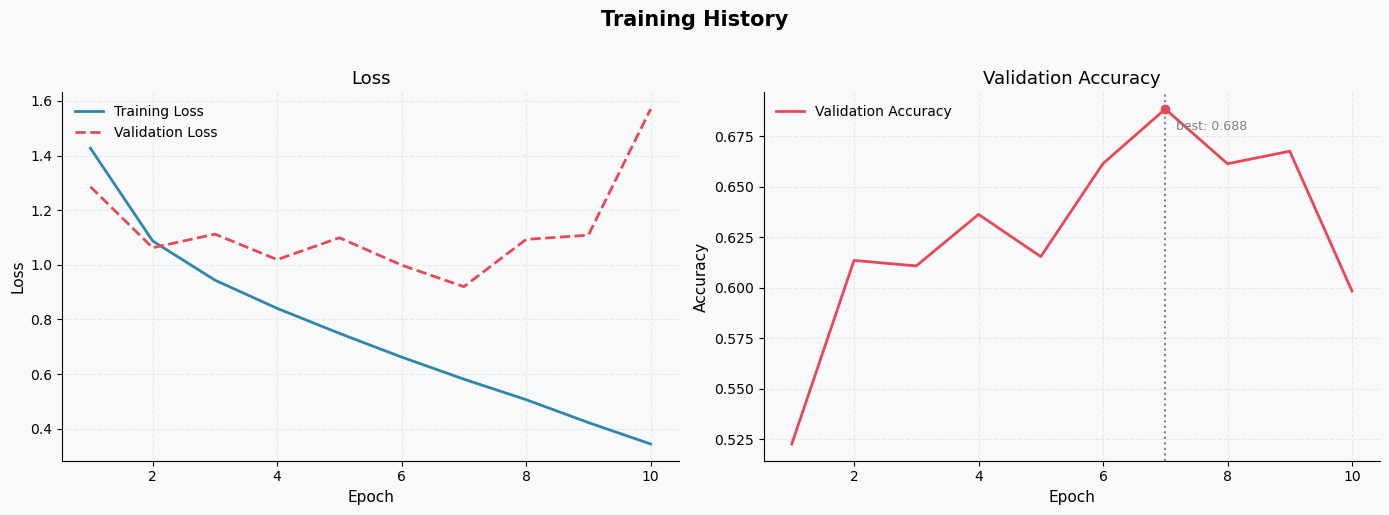

In [33]:
plot_training_history(model7_history)

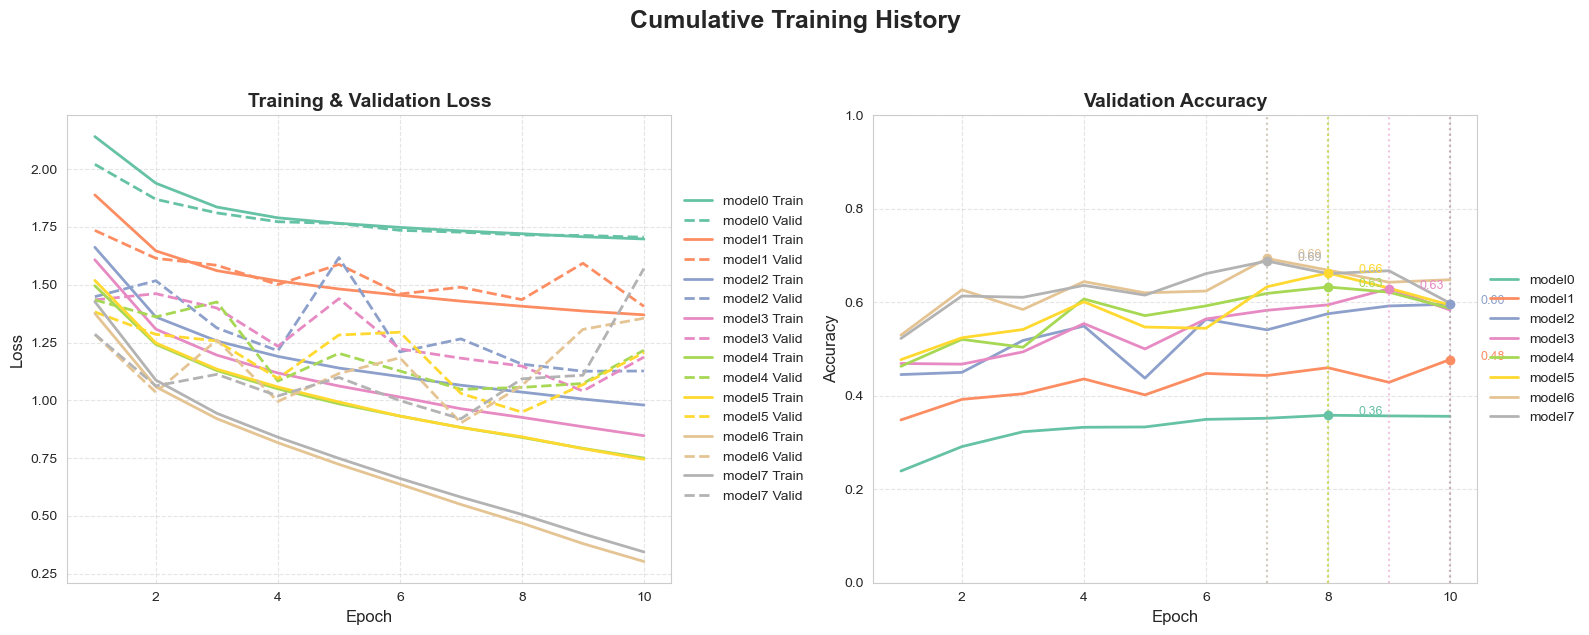

In [37]:
all_metrics_history = {
    "model0": model0_history,
    "model1": model1_history,
    "model2": model2_history,
    "model3": model3_history,
    "model4": model4_history,
    "model5": model5_history,
    "model6": model6_history,
    "model7": model7_history
}

plot_cumulative_training_history(all_metrics_history)

resuming to model5 since all the more complex models tend to overfit
adding more epochs and learning rate scheduler

In [ ]:
model8 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model8.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

In [43]:
set_seed(42)
model8_history = train(model8, train_loader, valid_loader, criterion, optimizer, scheduler, device=device, \
          num_epochs=20, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model8')

Epoch 1/20 | Train Loss: 1.5188 | Valid Loss: 1.3824 | Valid Acc: 0.4772
Epoch 2/20 | Train Loss: 1.2482 | Valid Loss: 1.2853 | Valid Acc: 0.5241
Epoch 3/20 | Train Loss: 1.1349 | Valid Loss: 1.2569 | Valid Acc: 0.5418
Epoch 4/20 | Train Loss: 1.0577 | Valid Loss: 1.0948 | Valid Acc: 0.6011
Epoch 5/20 | Train Loss: 0.9931 | Valid Loss: 1.2826 | Valid Acc: 0.5470
Epoch 6/20 | Train Loss: 0.9318 | Valid Loss: 1.2947 | Valid Acc: 0.5444
Epoch 7/20 | Train Loss: 0.8827 | Valid Loss: 1.0300 | Valid Acc: 0.6331
Epoch 8/20 | Train Loss: 0.8423 | Valid Loss: 0.9491 | Valid Acc: 0.6629
Epoch 9/20 | Train Loss: 0.7908 | Valid Loss: 1.0681 | Valid Acc: 0.6303
Epoch 10/20 | Train Loss: 0.7451 | Valid Loss: 1.2067 | Valid Acc: 0.5941
Epoch 11/20 | Train Loss: 0.7019 | Valid Loss: 1.2004 | Valid Acc: 0.5956
Epoch 12/20 | Train Loss: 0.6643 | Valid Loss: 1.1781 | Valid Acc: 0.6203
Epoch 13/20 | Train Loss: 0.5061 | Valid Loss: 0.9323 | Valid Acc: 0.6867
Epoch 14/20 | Train Loss: 0.4642 | Valid Loss: 

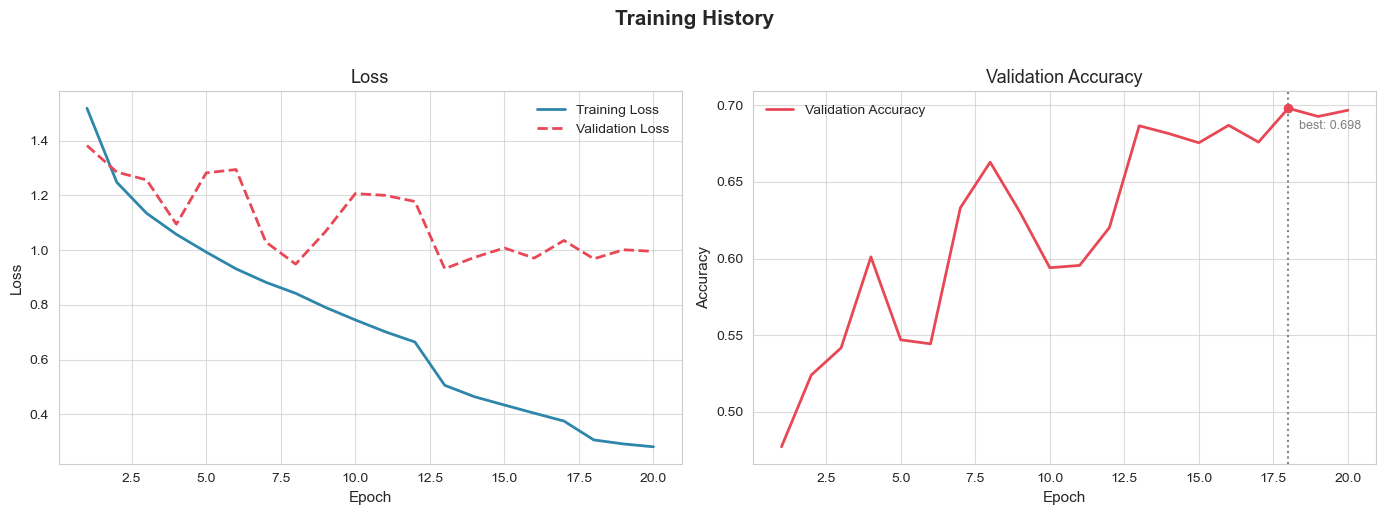

In [44]:
plot_training_history(model8_history)

still there is an overfit present but we'll be experimenting with regularization techniques later on

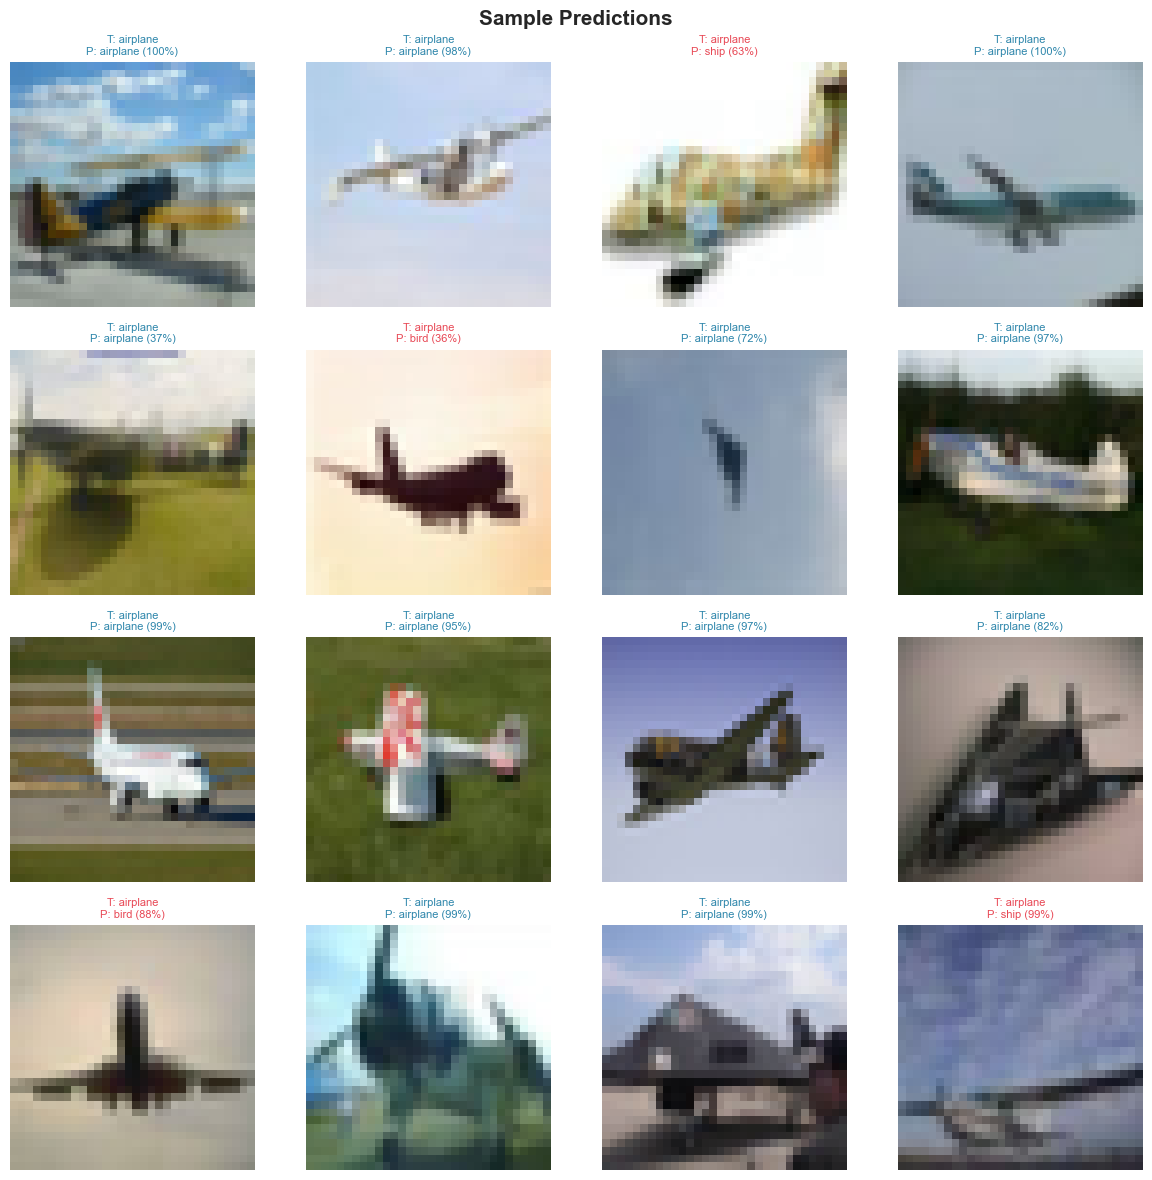

In [49]:
plot_sample_predictions(model8, valid_loader, device)

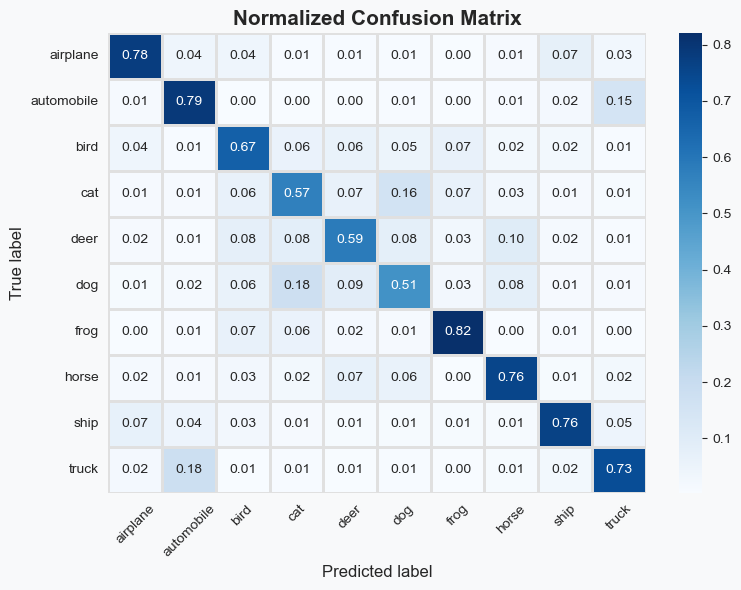

In [50]:
plot_confusion_matrix(model8, valid_loader, device)

In [ ]:
test_accuracy, avg_loss_test = evaluate_model(model8, test_loader, criterion, device)
print(f"Test accuracy: {test_accuracy}")
print(f"Average test loss: {avg_loss_test}")

Test accuracy: 0.6959221959114075
Average test loss: 1.00609327928755


In [51]:
torch.save({'epoch': 20, 'model_state_dict': model8.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
            'metrics_history': model8_history}, f'baseline.pth')